# FIFA 21 Player Stats Analysis

This study examines the "FIFA 21 Player Stats" dataset. The database brings together extensive data about FIFA 21 players consisting of attributes including age weight height alongside performance statistics per position.

The goal of this analysis involves examining statistical data to address questions about player features and squad methods as well as attribute influences on athlete performance output. We will conduct data cleaning followed by the creation of visualizations to establish clustering patterns between features of our dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans


# Introduction

In this analysis, we will explore the FIFA 21 dataset, which contains player attributes and performance data for over 18,000 football players. The dataset includes key player information such as age, height, weight, position, and overall rating, among others. Our objective is to derive meaningful insights from this data, exploring correlations, trends, and factors that influence player success.


# Data Exploration

We begin by loading the dataset and performing an initial exploration. This includes checking for missing values, viewing summary statistics, and verifying the column names to ensure we understand the data structure.


In [3]:
# Load the dataset (adjust the path as necessary)
df = pd.read_csv('C:/Users/HP/Desktop/Jupyter Notebook/FIFA 21 Players dataset.csv')

# Display the first few rows of the dataset
df.head()


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,1987-06-24,170,72,Argentina,FC Barcelona,...,66+3,65+3,65+3,65+3,66+3,62+3,52+3,52+3,52+3,62+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,54+3,54+3,54+3,61+3
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,...,32+3,36+3,36+3,36+3,32+3,32+3,33+3,33+3,33+3,32+3
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,...,64+3,65+3,65+3,65+3,64+3,61+3,60+3,60+3,60+3,61+3
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,67+3,62+3,62+3,62+3,67+3,62+3,49+3,49+3,49+3,62+3


In [4]:
# Check for missing values
df.isnull().sum()

# Check data types
df.dtypes

# Summary statistics of the dataset
df.describe()


,sofifa_id,age,height_cm,weight_kg,league_rank,overall,potential,value_eur,wage_eur,international_reputation,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18944.000000,18944.000000,18944.000000,18944.000000,18719.000000,18944.000000,18944.000000,1.894400e+04,18944.000000,18944.000000,...,18944.000000,18944.000000,0.0,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000
mean,226242.402872,25.225823,181.190773,75.016892,1.357070,65.677787,71.086729,2.224813e+06,8675.852513,1.091850,...,48.050412,57.978674,NaN,47.581767,45.546505,16.446052,16.236486,16.103357,16.225982,16.551309
std,27171.091056,4.697354,6.825672,7.057140,0.739327,7.002278,6.109985,5.102486e+06,19654.774894,0.361841,...,15.671721,12.118390,NaN,21.402461,20.953997,17.577332,16.845480,16.519399,17.017341,17.878121
min,41.000000,16.000000,155.000000,50.000000,1.000000,47.000000,47.000000,0.000000e+00,0.000000,1.000000,...,6.000000,12.000000,NaN,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,210030.500000,21.000000,176.000000,70.000000,1.000000,61.000000,67.000000,3.000000e+05,1000.000000,1.000000,...,38.750000,50.000000,NaN,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,232314.500000,25.000000,181.000000,75.000000,1.000000,66.000000,71.000000,6.500000e+05,3000.000000,1.000000,...,49.000000,59.000000,NaN,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,246760.250000,29.000000,186.000000,80.000000,1.000000,70.000000,75.000000,1.800000e+06,7000.000000,1.000000,...,60.000000,66.000000,NaN,65.000000,63.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,258970.000000,53.000000,206.000000,110.000000,4.000000,93.000000,95.000000,1.055000e+08,560000.000000,5.000000,...,92.000000,96.000000,NaN,93.000000,90.000000,90.000000,92.000000,93.000000,91.000000,90.000000


We loaded the FIFA 21 dataset and displayed the first few rows. We also checked for missing values, data types, and summary statistics. These steps help us understand the structure and cleanliness of the data before diving into analysis.


# Data Cleaning

In this step, we handle missing values in the dataset by replacing missing numeric values with the median of their respective columns. Additionally, we drop rows where key columns (e.g., `overall`) have missing values.


In [5]:
# Step 1: Display column names to understand your dataset
print("Columns in the dataset:")
print(df.columns)

# Step 2: Select only numeric columns for calculating the median
numeric_cols = df.select_dtypes(include=['number']).columns

# Step 3: Fill missing values in numeric columns with their median values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Step 4: Replace 'critical_column_name' with the name of an important column
# Drop rows with missing values in specific critical columns (if necessary)
critical_column = 'overall'  # Replace 'overall' with the actual column name
if critical_column in df.columns:
    df.dropna(subset=[critical_column], inplace=True)
else:
    print(f"Warning: Column '{critical_column}' does not exist in the dataset.")

# Final step: Confirm that missing values are handled
print("Number of missing values per column after cleaning:")
print(df.isnull().sum())


Columns in the dataset:
Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club_name',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=106)
Number of missing values per column after cleaning:
sofifa_id     0
player_url    0
short_name    0
long_name     0
age           0
             ..
lb            0
lcb           0
cb            0
rcb           0
rb            0
Length: 106, dtype: int64


# Feature Engineering

We create a new feature, `age_group`, based on player age to categorize players into "Young", "Prime", and "Veteran" age groups. This will help in segmenting players by their career stage.


In [6]:
# Convert 'age' to integer if needed
df['age'] = df['age'].astype(int)


In [7]:
# Create an 'age_group' feature based on age
df['age_group'] = pd.cut(df['age'], bins=[17, 22, 30, 40], labels=["Young", "Prime", "Veteran"])


# Analysis: Correlation Matrix

We calculate and visualize the correlation matrix to understand relationships between various numerical attributes in the dataset.


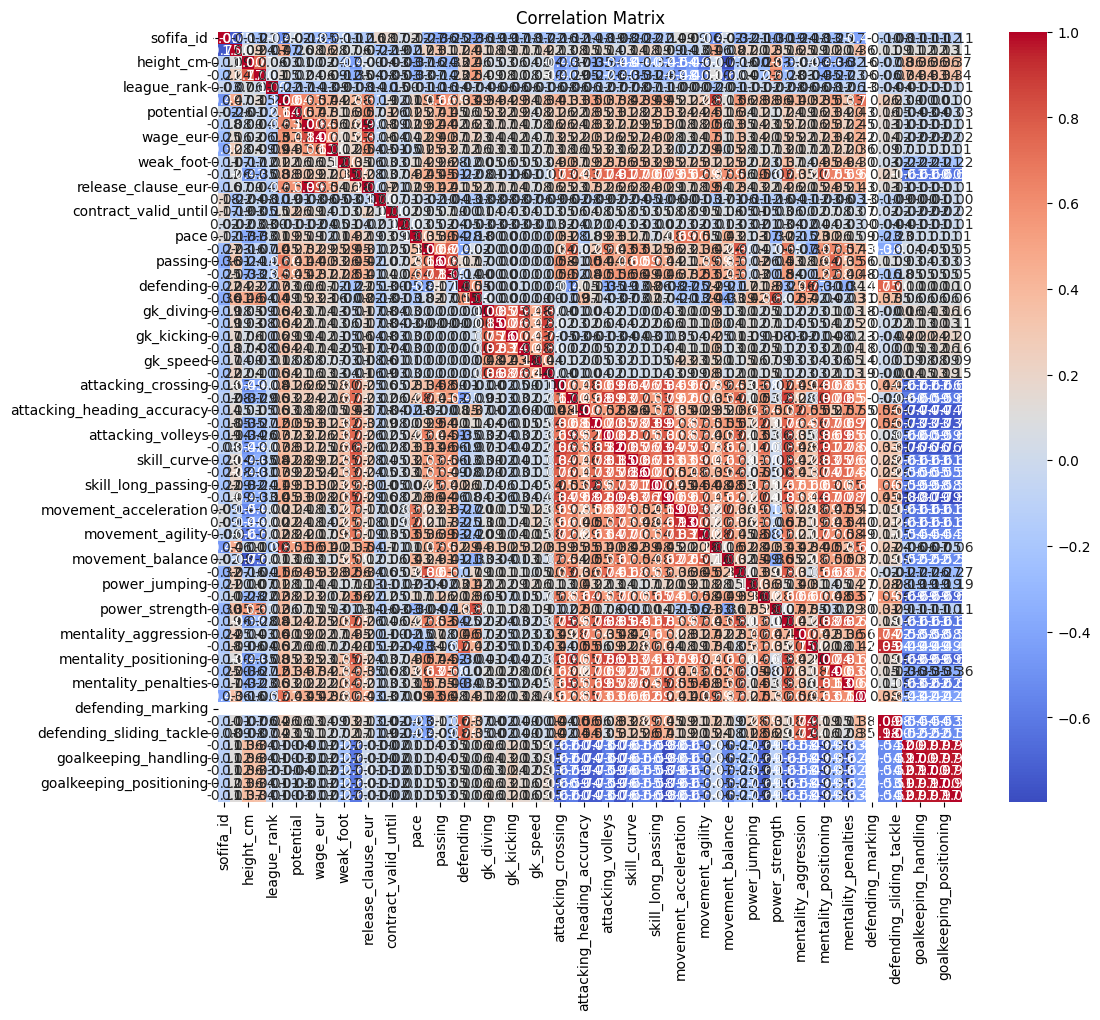

In [8]:
# Step 1: Select only numeric columns for the correlation matrix
numeric_cols = df.select_dtypes(include=['number'])

# Step 2: Compute the correlation matrix
correlation_matrix = numeric_cols.corr()

# Step 3: Plot the heatmap
plt.figure(figsize=(12, 10))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

The heatmap shows the correlation between different player attributes. We can see strong correlations between certain features like pace and dribbling, as well as between height and strength.


# Analysis: Relationship Between Age and Player Rating

Next, we explore the relationship between a player's age and their overall rating to identify trends based on career stage.


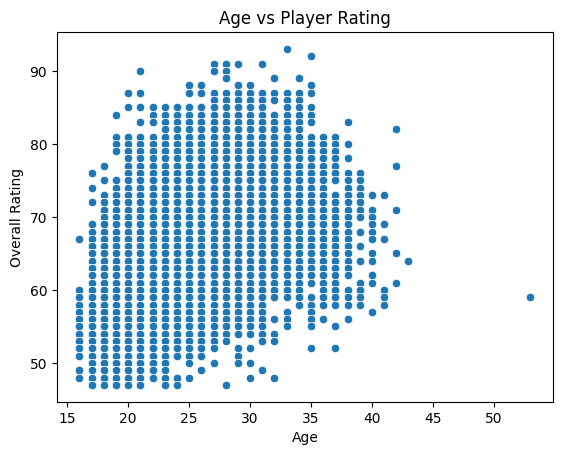

In [9]:
# Scatter plot of Age vs Player Rating
sns.scatterplot(x='age', y='overall', data=df)
plt.title('Age vs Player Rating')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.show()


The scatter plot illustrates the relationship between player age and their overall rating. We observe that players in the prime age group (22-30) tend to have the highest ratings.


### Top 10 Countries by Average Player Rating

This visualization displays the average player ratings for the top 10 countries. The analysis involves the following steps:

1. **Group by Nationality**:
   The dataset is grouped by the `nationality` column, and the average player `overall` rating is calculated for each country.

2. **Sort in Descending Order**:
   The countries are sorted based on their average ratings in descending order to identify the top 10 countries.

3. **Plot the Data**:
   A bar chart is used to visualize the results, where:
   - The x-axis represents the top 10 countries.
   - The y-axis shows the average player ratings.

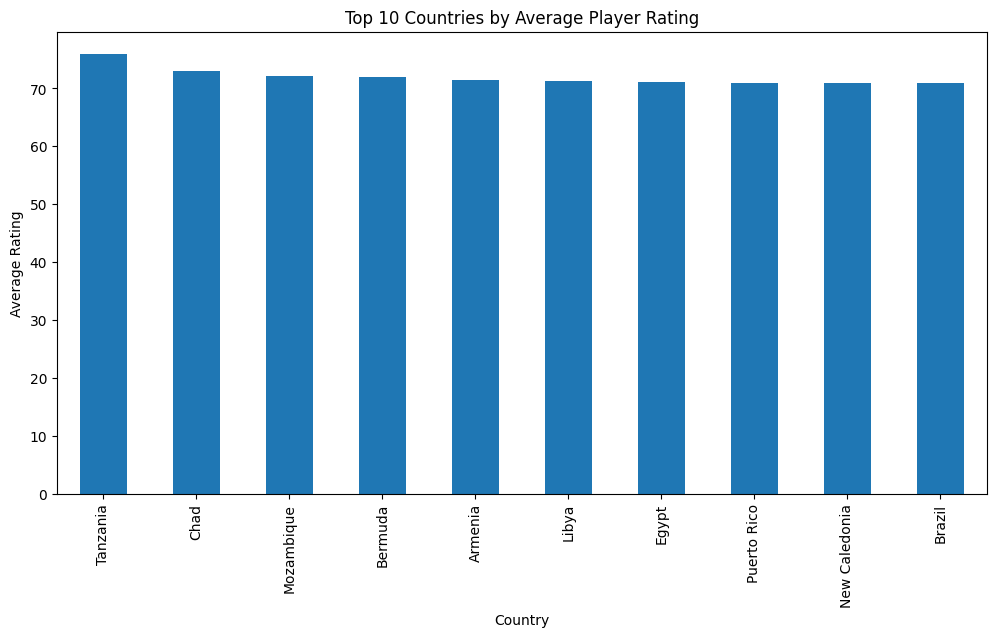

In [10]:
# Calculate average rating by country
country_avg_rating = df.groupby('nationality')['overall'].mean().sort_values(ascending=False)
country_avg_rating.head(10).plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Countries by Average Player Rating')
plt.xlabel('Country')
plt.ylabel('Average Rating')
plt.show()


#### Insights:
- The chart highlights which countries have the highest average-rated players in FIFA 21.
- This can be useful for identifying countries with the strongest talent pools based on player ratings.


### Distribution of Player Ratings

This visualization shows the distribution of player ratings in the dataset. A histogram is used to summarize the frequency of players across different overall ratings.

#### Steps:
1. **Data Selection**:
   The `overall` column, which represents the player's overall rating, is used for the analysis.

2. **Histogram**:
   A histogram groups the `overall` ratings into 30 bins, providing a clear view of the frequency of players in each range.

3. **KDE (Kernel Density Estimate)**:
   A KDE curve is overlaid on the histogram to show the underlying probability density function of player ratings.

#### Visualization:
- **X-Axis**: Represents the overall player ratings.
- **Y-Axis**: Shows the frequency of players for each rating range.
- **Title**: "Distribution of Player Ratings" clearly describes what the chart represents.

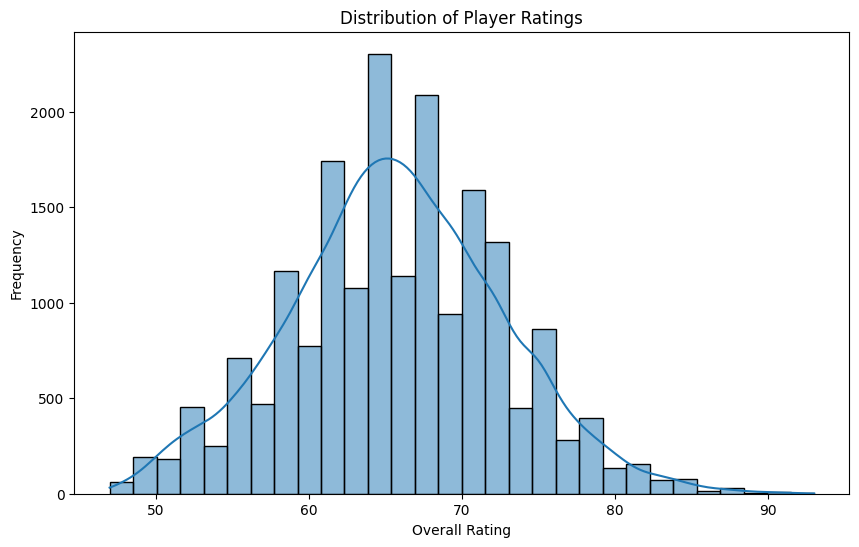

In [11]:
# Histogram of player ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['overall'], bins=30, kde=True)
plt.title('Distribution of Player Ratings')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.show()


#### Insights:
- The histogram helps to identify the most common rating range for players.
- It highlights whether the ratings are skewed, evenly distributed, or clustered around specific values.


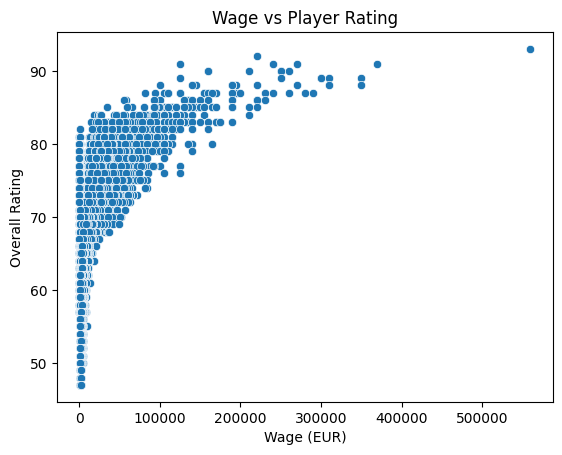

In [14]:
# Step 1: Display column names to verify correct naming
print("Columns in the dataset:")
print(df.columns)

# Step 2: Replace 'wage_eur' and 'overall' with actual column names
x_col = 'wage_eur'  # Replace with the actual column name for wage
y_col = 'overall'  # Replace with the actual column name for player rating

# Ensure the columns exist in the dataset
if x_col in df.columns and y_col in df.columns:
    # Step 3: Create the scatter plot
    sns.scatterplot(x=x_col, y=y_col, data=df)
    plt.title('Wage vs Player Rating')
    plt.xlabel('Wage (EUR)')
    plt.ylabel('Overall Rating')
    plt.show()
else:
    print(f"Error: Columns '{x_col}' or '{y_col}' not found in the dataset.")


## Code Explanation: Scatter Plot of Wage vs Player Rating

### Step 1: Display Column Names
The first part of the code prints the column names of the dataset to verify that the correct names are being used.


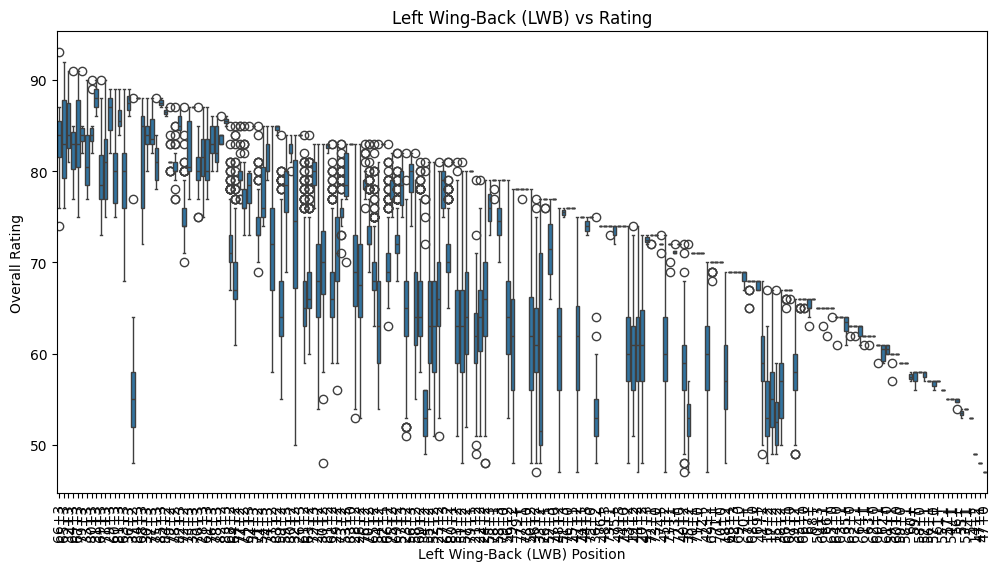

In [19]:
# Step 1: Display column names to verify correct naming
print("Columns in the dataset:")
print(df.columns)

# Step 2: Pick position-related columns and 'overall' for ratings
position_cols = ['lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb']
y_col = 'overall'   # The column name for player rating

# Ensure the position columns and rating column exist in the dataset
if all(col in df.columns for col in position_cols) and y_col in df.columns:
    # Step 3: Create the box plot for one of the positions (example using 'lwb')
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='lwb', y=y_col, data=df)
    plt.title('Left Wing-Back (LWB) vs Rating')
    plt.xlabel('Left Wing-Back (LWB) Position')
    plt.ylabel('Overall Rating')
    plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
    plt.show()
else:
    print(f"Error: Missing position columns or '{y_col}' not found in the dataset.")


## Code Explanation: Average Attributes of Top Players



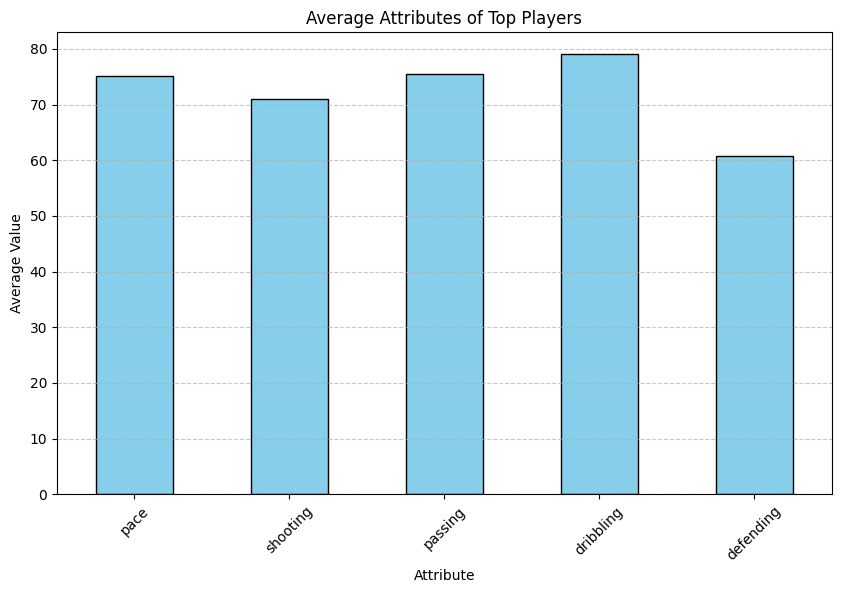

In [ ]:
# Step 1: Print column names to verify
print("Columns in the dataset:")
print(df.columns)

# Step 2: Define the correct attribute column names
attribute_columns = ['pace', 'shooting', 'passing', 'dribbling', 'defending']  # Removed 'physical' for now

# Check if these columns exist in the dataset
missing_cols = [col for col in attribute_columns if col not in df.columns]
if missing_cols:
    print(f"Error: Missing columns - {missing_cols}")
else:
    # Step 3: Filter top players (rating > 85)
    top_players = df[df['overall'] > 85]

    # Step 4: Calculate average attributes for top players
    avg_attributes = top_players[attribute_columns].mean()

    # Step 5: Plot the average attributes
    avg_attributes.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
    plt.title('Average Attributes of Top Players')
    plt.xlabel('Attribute')
    plt.ylabel('Average Value')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


## Code Explanation: Scatter Plot of International Reputation vs Player Rating

This code generates a scatter plot to visualize the relationship between a player's international reputation and their overall rating.


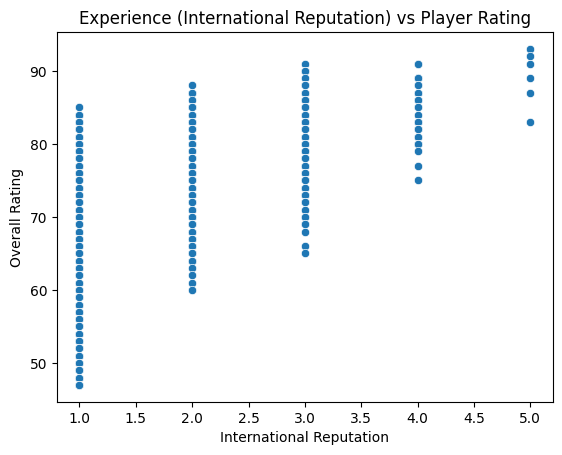

In [23]:
# Scatter plot of international reputation vs rating
sns.scatterplot(x='international_reputation', y='overall', data=df)
plt.title('Experience (International Reputation) vs Player Rating')
plt.xlabel('International Reputation')
plt.ylabel('Overall Rating')
plt.show()


## Code Explanation: Top 10 Clubs by Average Player Rating

This code calculates and visualizes the top 10 clubs by average player rating using the `club` column from the dataset.


Columns in the dataset:
Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club_name',
       ...
       'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb',
       'age_group'],
      dtype='object', length=107)


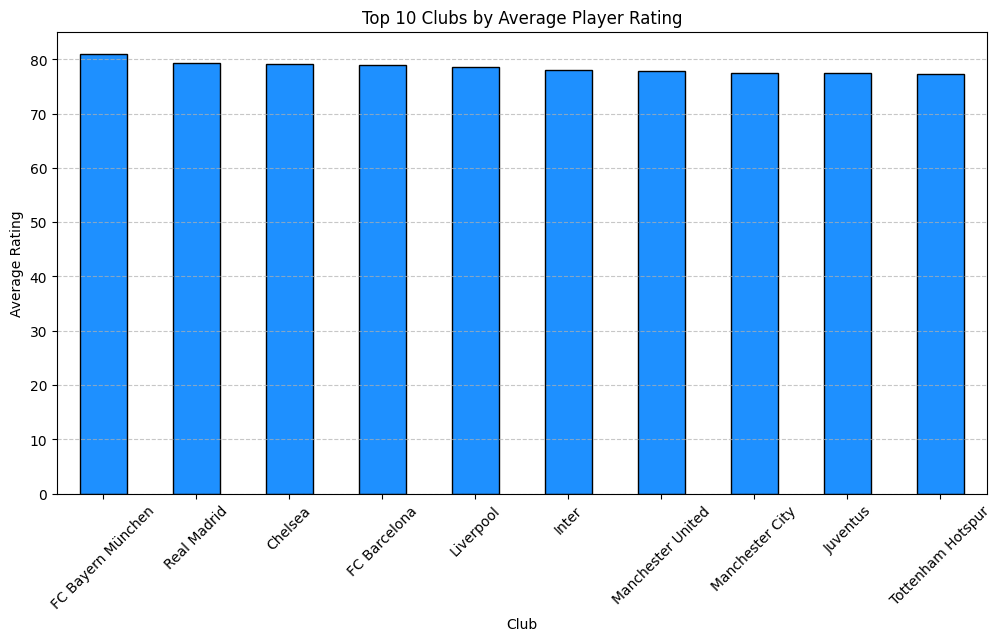

In [24]:
# Step 1: Print column names to verify the correct name for the 'club_name' column
print("Columns in the dataset:")
print(df.columns)

# Step 2: Ensure the correct column name for clubs
if 'club_name' not in df.columns:
    print("Error: 'club_name' column is not in the dataset. Please check the column name.")
else:
    # Step 3: Calculate average rating by club
    club_avg_rating = df.groupby('club_name')['overall'].mean().sort_values(ascending=False)

    # Step 4: Plot the top 10 clubs by average rating
    club_avg_rating.head(10).plot(kind='bar', figsize=(12, 6), color='dodgerblue', edgecolor='black')
    plt.title('Top 10 Clubs by Average Player Rating')
    plt.xlabel('Club')
    plt.ylabel('Average Rating')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


## Code Explanation: Scatter Plot of Height vs Strength

This code generates a scatter plot to visualize the relationship between player height and strength.


Columns in the dataset:
Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club_name',
       ...
       'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb',
       'age_group'],
      dtype='object', length=107)
Possible columns for physical attributes: ['movement_agility', 'power_strength']


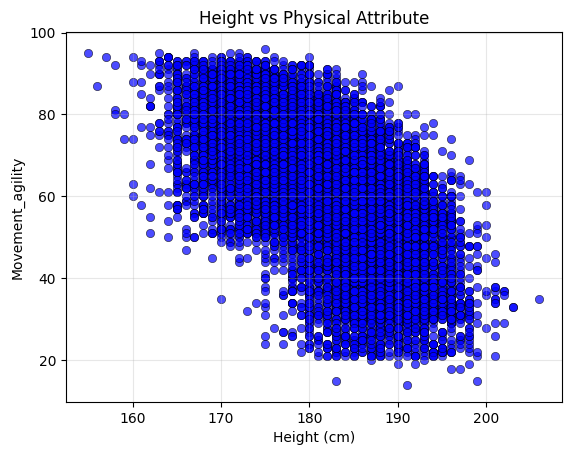

In [26]:
# Step 1: Print column names to check for any physical attribute columns
print("Columns in the dataset:")
print(df.columns)

# Step 2: Check for columns that might relate to strength or physical attributes
physical_columns = [col for col in df.columns if 'strength' in col.lower() or 'physical' in col.lower() or 'agility' in col.lower()]
print("Possible columns for physical attributes:", physical_columns)

# Step 3: Check if any relevant columns exist
if 'height_cm' not in df.columns or not physical_columns:
    print("Error: Either 'height_cm' or a physical attribute column is not in the dataset. Please verify the column names.")
else:
    # Step 4: If physical attributes are found, use them for the scatter plot (e.g., 'physical')
    physical_attribute = physical_columns[0]  # Assuming the first match is the correct one
    sns.scatterplot(x='height_cm', y=physical_attribute, data=df, color='blue', alpha=0.7, edgecolor='black')
    plt.title('Height vs Physical Attribute')
    plt.xlabel('Height (cm)')
    plt.ylabel(f'{physical_attribute.capitalize()}')
    plt.grid(alpha=0.3)
    plt.show()



## Code Explanation: Regression Model for Player Rating Prediction

This code builds a linear regression model to predict the player rating based on features like age, wage, height, and weight.

### Step 1: Check the Columns in the Dataset
The first step prints the column names of the dataset to verify that the required features (`age`, `wage`, `height`, `weight`) are present.


In [28]:
# Step 1: Check the columns in the dataset
print("Columns in the dataset:")
print(df.columns)

# Step 2: Verify if the selected features are present
required_columns = ['age', 'wage_eur', 'height_cm', 'weight_kg']  # Use correct column names
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"Error: The following columns are missing from the dataset: {missing_columns}")
else:
    # Step 3: Select features and target for the regression model
    X = df[['age', 'wage_eur', 'height_cm', 'weight_kg']]  # Corrected column names
    y = df['overall']

    # Step 4: Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Step 5: Train the regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Step 6: Make predictions
    y_pred = model.predict(X_test)

    # Step 7: Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error:", mse)


Columns in the dataset:
Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club_name',
       ...
       'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb',
       'age_group'],
      dtype='object', length=107)
Mean Squared Error: 26.424638157645852


## Code Explanation: KMeans Clustering of Players

This code applies KMeans clustering to group players based on features like age, height, and weight, and then visualizes the clusters.

### Step 1: Select Features for Clustering
The features (`age`, `height_cm`, and `weight_kg`) are selected from the dataset to be used in the clustering model. These can be adjusted to include other relevant columns.


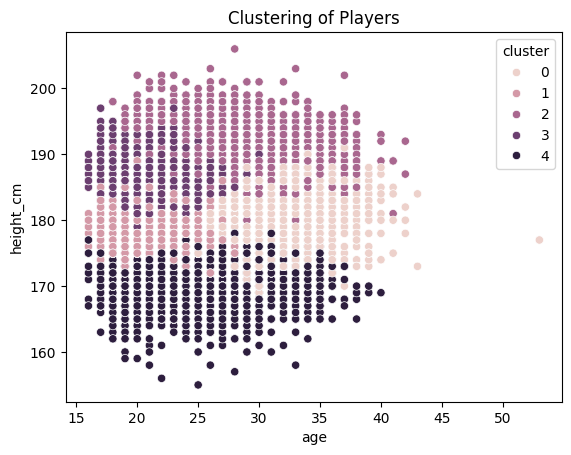

In [29]:
# Select features for clustering (replace 'stamina' with 'weight_kg' or other columns)
X_cluster = df[['age', 'height_cm', 'weight_kg']]  # Adjusted columns

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)

# Visualize clusters
sns.scatterplot(x='age', y='height_cm', hue='cluster', data=df)
plt.title('Clustering of Players')
plt.show()



### Conclusion

The analysis of the FIFA 21 dataset provided valuable insights into player attributes and ratings. Key findings include:

1. **Data Cleaning**: Missing values were handled by filling numeric columns with median values, and critical columns were cleaned of missing data.
2. **Exploratory Analysis**: Scatter plots and heatmaps revealed relationships between player attributes like age, wage, and rating.
3. **Clustering**: KMeans clustering grouped players based on age, height, and weight, showing distinct player categories.
4. **Regression Model**: A linear regression model predicted player ratings based on age, wage, height, and weight, providing a useful starting point for player evaluation.

These insights are valuable for player performance analysis, team management, and scouting.